In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("imdb")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print("Train:", train_df.shape)
print("Test:", test_df.shape)

train_df.head()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Train: (25000, 2)
Test: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [ ]:
print("Пропуски:")
print(train_df.isnull().sum())

print("\nДубликаты:", train_df.duplicated().sum())

# классы
print("\nРаспределение классов:")
print(train_df["label"].value_counts())

Пропуски:
text     0
label    0
dtype: int64

Дубликаты: 96

Распределение классов:
label
0    12500
1    12500
Name: count, dtype: int64


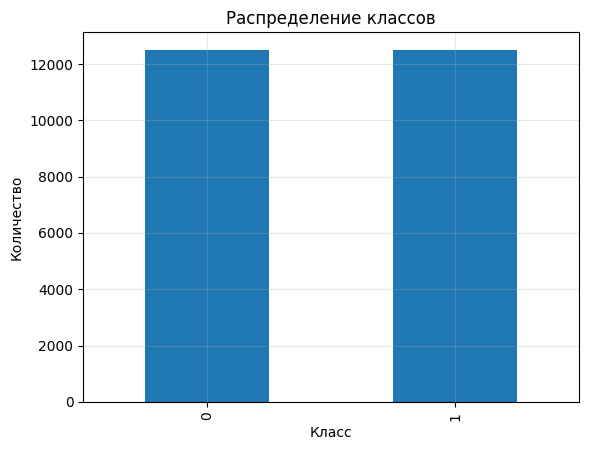

In [ ]:
import matplotlib.pyplot as plt

train_df["label"].value_counts().plot(kind="bar")
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

count    25000.000000
mean       236.844200
std        175.993044
min         10.000000
25%        129.000000
50%        177.000000
75%        287.000000
max       2494.000000
Name: len, dtype: float64


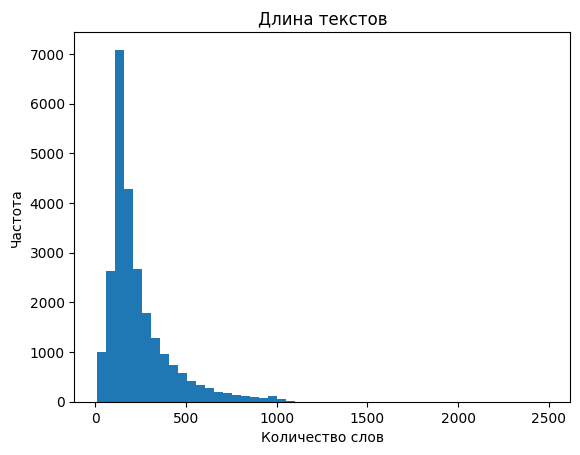

In [ ]:
train_df["len"] = train_df["clean_text"].apply(lambda x: len(x.split()))

print(train_df["len"].describe())

plt.hist(train_df["len"], bins=50)
plt.title("Длина текстов")
plt.xlabel("Количество слов")
plt.ylabel("Частота")
plt.show()

In [ ]:
max_len = int(train_df["len"].quantile(0.95))
print("max_len:", max_len)

max_len: 608


In [ ]:
from sklearn.model_selection import train_test_split

X = train_df["clean_text"].values
y = train_df["label"].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_test = test_df["clean_text"].values
y_test = test_df["label"].values

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

VOCAB_SIZE = 20000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential([
    Embedding(VOCAB_SIZE, 128),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 426s 3s/step - accuracy: 0.7240 - loss: 0.5288 - val_accuracy: 0.8030 - val_loss: 0.4375
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 408s 3s/step - accuracy: 0.8873 - loss: 0.2945 - val_accuracy: 0.8752 - val_loss: 0.3290
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 408s 3s/step - accuracy: 0.9319 - loss: 0.1970 - val_accuracy: 0.8670 - val_loss: 0.3354
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.9595 - loss: 0.1260 - val_accuracy: 0.8716 - val_loss: 0.3821


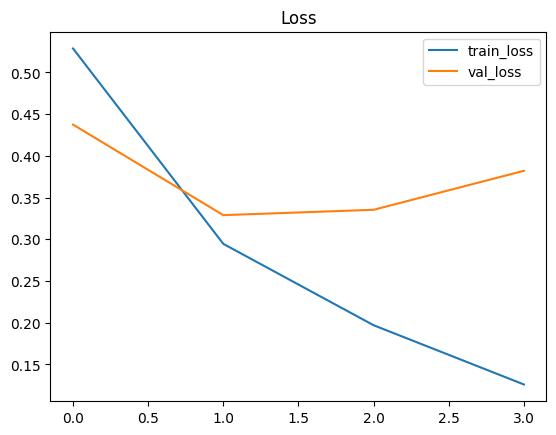

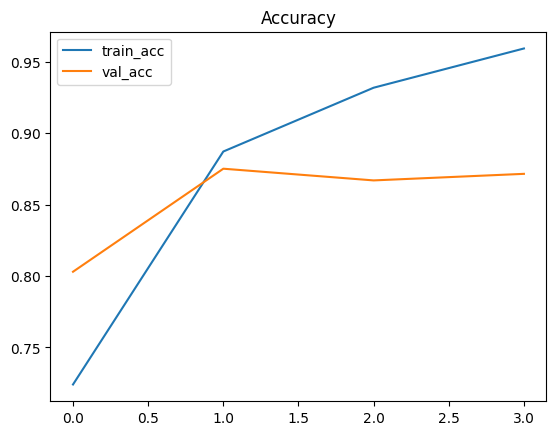

In [ ]:
import pandas as pd

history_df = pd.DataFrame(history.history)

plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.plot(history_df["accuracy"], label="train_acc")
plt.plot(history_df["val_accuracy"], label="val_acc")
plt.legend()
plt.title("Accuracy")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

y_pred = (model.predict(X_test_pad) > 0.5).astype(int).flatten()

acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 137s 174ms/step
Accuracy: 0.8564
Precision: 0.8405
Recall: 0.8799
F1: 0.8597


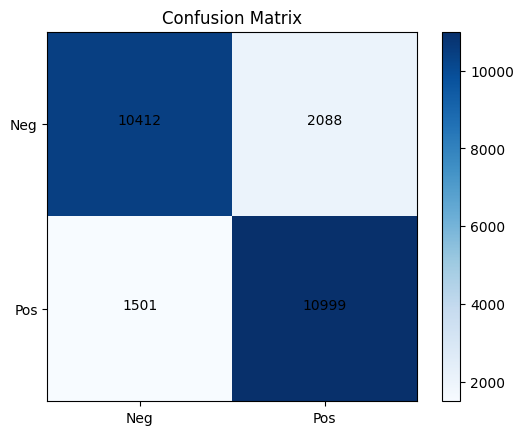

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks([0,1], ["Neg","Pos"])
plt.yticks([0,1], ["Neg","Pos"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center")

plt.show()